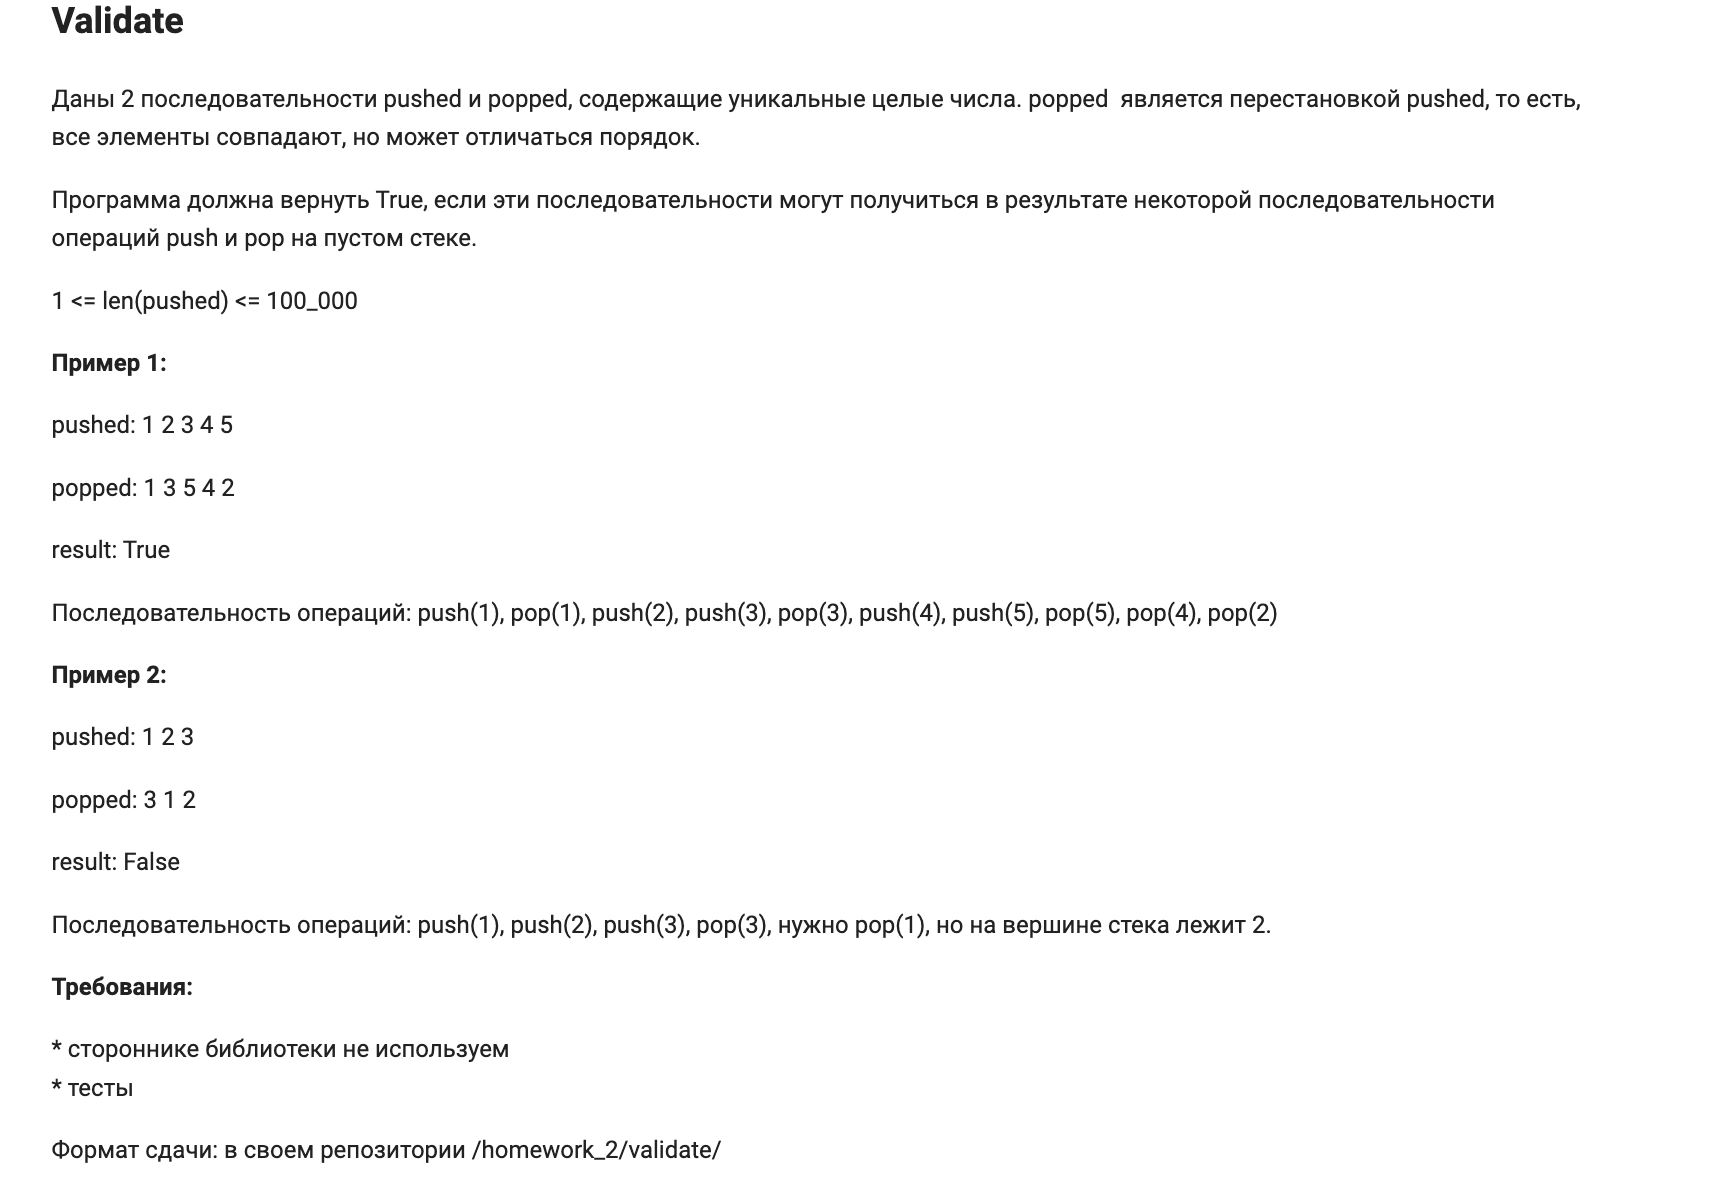

## Ход решения

- Заводим пустой стек `stack`, в который будем по очереди добавлять элементы из `pushed`.

- Заводим счётчик `j = 0`:
  - `j` одновременно является индексом в массиве `popped`;
  - `popped[j]` — это элемент, который мы хотим извлечь из стека следующим.

- Идём по `pushed` слева направо обычным циклом `for`.

- Каждый очередной элемент добавляем в `stack`.

- После добавления проверяем вершину стека:
  - если `stack[-1] == popped[j]`, значит нужный элемент сейчас находится сверху и его можно извлечь;
  - делаем `pop()` и увеличиваем `j` на 1;
  - после этого `popped[j]` уже соответствует следующему элементу, который мы хотим получить.

- Проверку делаем через `while`, потому что после одного `push` может оказаться возможным извлечь сразу несколько элементов подряд.

- В конце проверяем, дошёл ли `j` до конца `popped`:
  - если `j == len(popped)`, значит все элементы удалось извлечь в нужном порядке и возвращаем `True`;
  - иначе возвращаем `False`.

Как только вершина стека совпала с `popped[j]`, этот элемент можно сразу извлекать. Если оставить его в стеке и сделать ещё один `push`, новый элемент просто окажется поверх него и не поможет получить нужный порядок.

## Сложность алгоритма

Пусть `n = len(pushed)`.

Каждый элемент:

- один раз добавляется в стек;
- не более одного раза удаляется из стека.

Поэтому суммарное число операций линейно.

| Что | Сложность |
| --- | ---: |
| Время | `O(n)` |
| Доп. память | `O(n)` |

В худшем случае все элементы сначала попадут в стек, поэтому стек может содержать до `n` элементов одновременно.

# Реализация

Реализуем функцию `validate`.

По условию элементы уникальны, а `popped` является перестановкой `pushed`, поэтому отдельно проверять совпадение наборов элементов не требуется.

In [1]:
def validate(pushed,popped):
    stack = []
    j = 0
    for value in pushed:
        stack.append(value)
        while stack != [] and j < len(popped) and stack[-1] == popped[j]:
            stack.pop()
            j += 1

    return j == len(popped)

# Визуализация работы алгоритма

## Пример 1

```text
pushed = [1, 2, 3, 4, 5]
popped = [1, 3, 5, 4, 2]
```

| Шаг | Операция | Стек после операции | Следующий ожидаемый `pop` |
| --- | --- | --- | ---: |
| 1 | `push(1)` | `[1]` | `1` |
| 2 | `pop(1)` | `[]` | `3` |
| 3 | `push(2)` | `[2]` | `3` |
| 4 | `push(3)` | `[2, 3]` | `3` |
| 5 | `pop(3)` | `[2]` | `5` |
| 6 | `push(4)` | `[2, 4]` | `5` |
| 7 | `push(5)` | `[2, 4, 5]` | `5` |
| 8 | `pop(5)` | `[2, 4]` | `4` |
| 9 | `pop(4)` | `[2]` | `2` |
| 10 | `pop(2)` | `[]` | — |

Все элементы удалось извлечь в порядке `popped`, поэтому результат — `True`.

## Пример 2

```text
pushed = [1, 2, 3]
popped = [3, 1, 2]
```

После `push(1)`, `push(2)`, `push(3)` стек выглядит так:

```text
[1, 2, 3]
```

Извлекаем `3`, получаем:

```text
[1, 2]
```

Следующим по `popped` нужен `1`, но на вершине стека находится `2`. Новых элементов в `pushed` больше нет, поэтому получить `1` раньше `2` невозможно.

Результат — `False`.

# Тесты

Тесты проверяют:

- оба примера из условия;
- одинаковый порядок `pushed` и `popped`;
- полностью обратный порядок;
- последовательность из одного элемента;
- корректный случай с несколькими `pop` подряд;
- некорректный порядок в середине последовательности;
- большой вход из `100_000` элементов, соответствующий ограничению из условия.

In [2]:
assert validate(
    [1, 2, 3, 4, 5],
    [1, 3, 5, 4, 2],
)

assert not validate(
    [1, 2, 3],
    [3, 1, 2],
)

assert validate(
    [1, 2, 3, 4],
    [1, 2, 3, 4],
)

assert validate(
    [1, 2, 3, 4],
    [4, 3, 2, 1],
)

assert validate(
    [1],
    [1],
)

assert validate(
    [1, 2, 3, 4, 5],
    [2, 1, 5, 4, 3],
)

assert not validate(
    [1, 2, 3, 4],
    [3, 1, 2, 4],
)

n = 100_000
assert validate(
    list(range(n)),
    list(range(n - 1, -1, -1)),
)

print("Все тесты пройдены")


Все тесты пройдены
